# Image Classification with PyTorch: AlexNet and ResNet

[Pablo Carballeira] (http://dymas.ii.uam.es/webvpu/gti/user/186/), Escuela Politecnica Superior, Universidad Autónoma de Madrid.

Parts of this code have been adapted from then work of Kevin McGuinness (http://www.eeng.dcu.ie/~mcguinne/), School of Electronic Engineering, Dublin City University, and the work of Ben Trevett (https://github.com/bentrevett), Heriot-Watt University

You can find documentation about working in Colab here (https://colab.research.google.com/notebooks/intro.ipynb)

---

In this lab assignment you will learn how to use the [PyTorch](https://pytorch.org/) deep learning framework to create and train a modified version of the AlexNet model and a simplified ResNet model for image classification. You will use the [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset that contains 10 classes of color images

# Instructions

Anywhere you see a **???** in the code below, fill in in with the correct code.

# Import packages

Find the PyTorch docs at https://pytorch.org/docs/stable/index.html

Tutorials: https://pytorch.org/tutorials/

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import _LRScheduler
import torch.utils.data as data
from torch.utils.data import DataLoader

import torchvision.transforms as transforms
import torchvision.datasets as datasets

from sklearn import decomposition
from sklearn import manifold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

import copy
import random
import time

# Enable GPU acceleration

Open to the Edit menu and select *Notebook settings* and check that *GPU* is selected under hardware accelerator.


In [45]:
# make sure to enable GPU acceleration!
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


We set the random seed so all of our experiments can be reproduced.

In [46]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Dataset: CIFAR10

We are now moving on from the MNIST dataset and we will be using the [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset. CIFAR10 consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. The classes are: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

![](https://github.com/bentrevett/pytorch-image-classification/blob/master/assets/cifar10.png?raw=1)



# Dataset pre-processing


## Mean and standard deviation of the dataset

As mentioned in the previous notebook, for those models that do not use early batch normalization, it is important to transform the dataset so that the images have mean zero and unit variance.

Here, we calculate the mean and standard deviation of our data so we can normalize it appropiately. CIFAR10 is made up of color images with three color channels (red, green and blue). To normalize the data we need to calculate the means and standard deviations for each of the color channels independently.



In [47]:
ROOT = '.data/CIFAR10'

train_data = datasets.CIFAR10(root = ROOT,
                              train = True,
                              download = True)

# use the functions that are built in the dataset to obtain the means and stds.
# Bear in mind that image pixels are in the [0,255] range, but they are converted to
# the [0,1] range when transformed to Tensor variables
means = train_data.data.mean(axis = (0,1,2)) / 255
stds = train_data.data.std(axis = (0,1,2)) / 255

print(f'Calculated means: {means}')
print(f'Calculated stds: {stds}')

Calculated means: [0.49139968 0.48215841 0.44653091]
Calculated stds: [0.24703223 0.24348513 0.26158784]



Next up is defining the transforms for the training and validation sets.



In [48]:
# define the train and tesst transforms with normalization with the means and
# stds we have just computed
train_transforms = transforms.Compose([

    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

valid_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

Next, as standard, we'll load the dataset with our transforms...

In [49]:
train_set = datasets.CIFAR10(root=ROOT,
                             train=True,
                             download=True,
                             transform=train_transforms)

valid_set = datasets.CIFAR10(root=ROOT,
                             train=False,
                             download=True,
                             transform=valid_transforms)

We print out the number of examples in each set of data to ensure everything has gone OK so far.

In [50]:
print(f'Number of training examples: {len(train_set)}')
print(f'Number of validation examples: {len(valid_set)}')

Number of training examples: 50000
Number of validation examples: 10000


## Dataset examples

We will use `matplotlib` to see some examples of the CIFAR10 dataset



`matplotlib` expects the values of every pixel to be between $[0, 1]$. However our normalization will cause them to be outside this range. A solution to this is to renormalize the images so each pixel is between $[0, 1]$, so we'll write a function that does it and we can use whenever we need to renormalize an image.

In [51]:
def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

Now, we'll create a function to plot some of the images in our dataset to see what they actually look like.

Note that by default PyTorch handles images that are arranged `[channel, height, width]`, but `matplotlib` expects images to be `[height, width, channel]`, hence we need to `permute` our images before plotting them.

In [52]:
def plot_images(images, labels, classes, normalize = False):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize = (10, 10))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]
        image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

Then, we'll actually plot the images.

We get both the images and the labels from the training set and convert the labels, which are originally stored as integers, into their human readable class by using the data's `classes` dictionary.

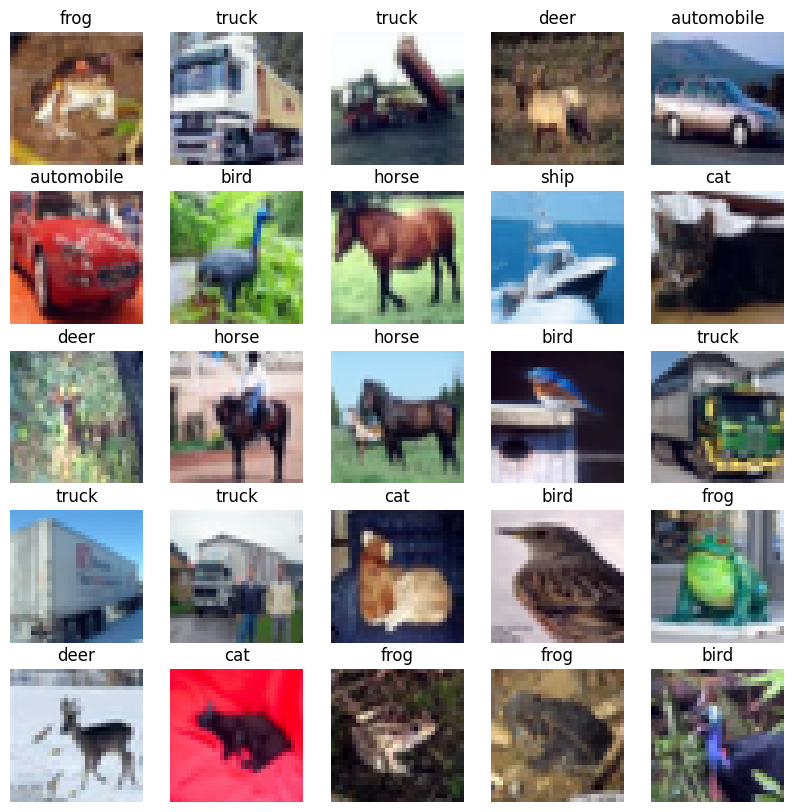

In [53]:
N_IMAGES = 25

images, labels = zip(*[(image, label) for image, label in
                           [train_set[i] for i in range(N_IMAGES)]])
classes = valid_set.classes
plot_images(images, labels, classes, normalize = True)

The final bit of the data processing is creating the iterators.

We will use here a larger batch size. Generally, when using a GPU, a larger batch size means our model trains faster. Our model has significantly more parameters and the images it is training on are much larger, than the previous notebook, so will generally take longer. We offset this as much as we can by using a batch size of 256.

In [54]:
BATCH_SIZE = 256
train_loader = DataLoader(train_set,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

valid_loader = DataLoader(valid_set,
                          batch_size=BATCH_SIZE,
                          shuffle=False)

# AlexNet

In this notebook we will be implementing a modified version of [AlexNet](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf), a neural network model that uses convolutional neural network (CNN) layers and was designed for the [ImageNet challenge](http://www.image-net.org/challenges/LSVRC/). AlexNet is famous for winning the ImageNet challenge in 2012 by beating the second place competitor by over 10% accuracy and kickstarting the interest in deep learning for computer vision.

The image below shows the original architecture of AlexNet. There are two "paths" of processing through the network. This is due to the original AlexNet model being implemented on two GPUs in parallel. Almost all implementations of AlexNet are now on a single GPU and our implementation is too. In a single-GPU implementation, both paths are combined by doubling the number of feature channels in each layer (adds up the number of feature channels in each path)

![](https://github.com/bentrevett/pytorch-image-classification/blob/master/assets/alexnet.png?raw=1)



# Defining the Model

The AlexNet model itself is not conceptually very different from the simple CNN model of the previous notebook. It is made up of convolutional layers, pooling layers, ReLU activation functions and Dropout layers.

AlexNet was designed for ImageNet, that comprises 224x224 color images. Here, we are using 32x32 images of the CIFAR10 dataset, so we will adapt the original AlexNet architecture with the following modifications:

* the inputs are 32x32 color images
* only one branch of the model will be implemented, so the layers will have half the number of channels than in the complete version (the complete version doubles the number of channels in a single branch)
*  Local Response Normalization layers are skipped

The sequential order you have to implement for convolutional layers, max pooling layers, and fully-connected layres is depicted in the following scheme following. Make sure:
*  5x5 kernels are used in the first conv layer, instead of the original 11x11 kernel size
*  2x2 max pooling kernels are used
*  ReLU activations are used after the max pooling layer (if it is present). If not, after the convolutional or linear layer.
*  Dropout with probability 0.5 is added before the first and second fully-connected layers


![](https://media.geeksforgeeks.org/wp-content/uploads/20200315210219/AlexNet.png)



## Model definition: Sequential

`Sequential` is used to compact the code for the definition of the network. We use `Sequential` to define the multiple layers of the CNN and when the `Sequential` module is called it will apply each layer, in order, to the input. There is no difference between using a `Sequential` and having each module defined in the `__init__` and then called in `forward` - however it makes the code significantly shorter.

We will create one `Sequential` model, `features`, for all the convolutional and pooling layers, then we flatten the data, and pass it to another `Sequential` model, `classifier`,  which is made up of linear layers.


One last thing to mention is that the very first convolutional layer has an `in_channel` of three. That is because we are handling color images that have three channels (red, green and blue) instead of the single channel grayscale images from the MNIST dataset. This doesn't change the way any of the convolutional filter works, it just means the first filter has a depth of three instead of a depth of one.



Note that the model is defined with the number of output classes as a parameter (defined by the number of classes of the dataset)

In [55]:
class AlexNet(nn.Module):
    def __init__(self, output_dim):
        super().__init__()

        self.features = nn.Sequential(
            # First convolutional layer. Use 5x5 kernel instead of 11x11
            nn.Conv2d(3, 48, 5, 2, 2), #in_channels, out_channels, kernel_size, stride, padding
            nn.MaxPool2d(2), #kernel_size
            nn.ReLU(inplace = True),
            # Complete the following four conv layers of the AlexNet model.
            # Subsampling is only performed by 2x2 max pooling layers (not with stride in the
            # convolutional layers)
            # Pay special attention to the number of input and output channels of each layer
            # Second convolutional layer
            nn.Conv2d(48, 128, 5, 1, 2), # in: 48, out: 128, kernel: 5, stride: 1, padding: 2
            nn.MaxPool2d(2),
            nn.ReLU(inplace = True),

            # Third convolutional layer
            nn.Conv2d(128, 192, 3, 1, 1), # in: 128, out: 192, kernel: 3, stride: 1, padding: 1
            nn.ReLU(inplace = True), # No max pooling here

            # Fourth convolutional layer
            nn.Conv2d(192, 192, 3, 1, 1), # in: 192, out: 192, kernel: 3, stride: 1, padding: 1
            nn.ReLU(inplace = True), # No max pooling here

            # Fifth convolutional layer
            nn.Conv2d(192, 128, 3, 1, 1), # in: 192, out: 128, kernel: 3, stride: 1, padding: 1
            nn.MaxPool2d(2),
            nn.ReLU(inplace = True)

        )

        self.classifier = nn.Sequential(
            # First linear layer
            nn.Dropout(0.5),
            nn.Linear(128 * 2 * 2, 2048), # final conv layer resolution 2x2
            nn.ReLU(inplace = True),
            # second linear layer
            nn.Dropout(0.5),
            nn.Linear(2048, 2048),
            nn.ReLU(inplace = True),

            # Last Linear layer. No ReLU
            nn.Linear(2048, output_dim),
        )

    def forward(self, x):
        x = self.features(x)
        interm_features = x.view(x.shape[0], -1)
        x = self.classifier(interm_features)
        return x, interm_features

The code below is used to check that the model architecture is defined correctly. The code should not return any error, and the output should be the following:

```
Output size:  torch.Size([1, 5])
Output:tensor([[-0.0030, -0.0120,  0.0230,  0.0213, -0.0198]],
       grad_fn=<AddmmBackward0>)
```



In [56]:
SEED = 1234
torch.manual_seed(SEED)

dummy_input = torch.rand(1,3,32,32)
model = AlexNet(5)
output = model(dummy_input)

print('Output size: ',format(output[0].shape))
print('Output:')
print(output[0])

Output size:  torch.Size([1, 5])
Output:
tensor([[-0.0030, -0.0120,  0.0230,  0.0213, -0.0198]],
       grad_fn=<AddmmBackward0>)


We'll create an instance of our model with the desired amount of classes.

In [57]:
model = AlexNet(10)

model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 48, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU(inplace=True)
    (3): Conv2d(48, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(192, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): ReLU(inplace=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=512, out_features=2048, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inp

Then we'll see how many trainable parameters our model has. AlexNet is a relatively small model for computer vision.


In [58]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 6,199,498 trainable parameters


# Training the Model

Use the code from previous notebook to train the model for 15 epochs, using the same parameters for the optimizer, and plot the learning curves



Starting training...
Epoch: 01 | Epoch Time: 0m 18s
	Train Loss: 1.737 | Train Acc: 32.82%
	 Val. Loss: 1.392 |  Val. Acc: 48.23%
Epoch: 02 | Epoch Time: 0m 18s
	Train Loss: 1.314 | Train Acc: 52.09%
	 Val. Loss: 1.240 |  Val. Acc: 55.21%
Epoch: 03 | Epoch Time: 0m 18s
	Train Loss: 1.117 | Train Acc: 60.47%
	 Val. Loss: 1.050 |  Val. Acc: 62.44%
Epoch: 04 | Epoch Time: 0m 18s
	Train Loss: 0.972 | Train Acc: 65.72%
	 Val. Loss: 1.031 |  Val. Acc: 64.16%
Epoch: 05 | Epoch Time: 0m 20s
	Train Loss: 0.866 | Train Acc: 69.96%
	 Val. Loss: 1.002 |  Val. Acc: 66.13%
Epoch: 06 | Epoch Time: 0m 18s
	Train Loss: 0.775 | Train Acc: 73.01%
	 Val. Loss: 1.005 |  Val. Acc: 66.39%
Epoch: 07 | Epoch Time: 0m 18s
	Train Loss: 0.690 | Train Acc: 76.23%
	 Val. Loss: 0.933 |  Val. Acc: 69.54%
Epoch: 08 | Epoch Time: 0m 18s
	Train Loss: 0.613 | Train Acc: 78.74%
	 Val. Loss: 0.925 |  Val. Acc: 69.93%
Epoch: 09 | Epoch Time: 0m 18s
	Train Loss: 0.534 | Train Acc: 81.69%
	 Val. Loss: 0.986 |  Val. Acc: 69.32

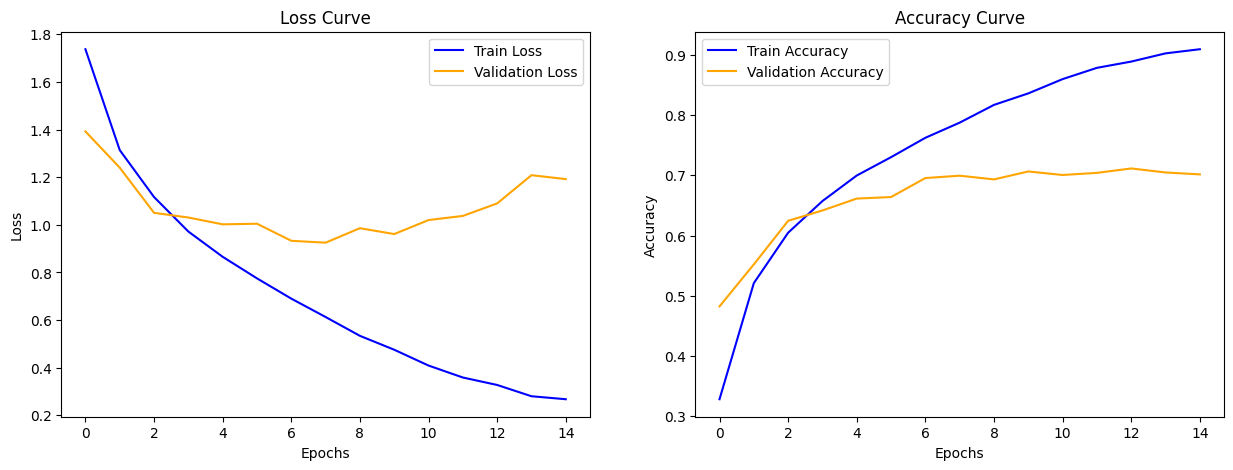

In [59]:

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
criterion = criterion.to(device)


def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc


def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc = 0
    model.train()

    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred, _ = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)


def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc = 0
    model.eval()

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)

            y_pred, _ = model(x)
            loss = criterion(y_pred, y)
            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

EPOCHS = 15

train_losses = []
valid_losses = []
train_accs = []
valid_accs = []

best_valid_loss = float('inf')

print("Starting training...")
for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)

    # Save the best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'alexnet-model.pt')

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {int(epoch_mins)}m {int(epoch_secs)}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

# 6. Plot Learning Curves
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
ax[0].plot(train_losses, label='Train Loss', color='blue')
ax[0].plot(valid_losses, label='Validation Loss', color='orange')
ax[0].set_title('Loss Curve')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Plot Accuracy
ax[1].plot(train_accs, label='Train Accuracy', color='blue')
ax[1].plot(valid_accs, label='Validation Accuracy', color='orange')
ax[1].set_title('Accuracy Curve')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.show()

# Error analysis

Here we will take a look at the validation samples that the model got wrong. This is often a good idea when trying to improve a models, since it gives you some intuition about the kinds of examples the model finds difficult, which can lead to insights on how to improve models.

We'll examine our model by: plotting a confusion matrix, seeing which incorrect examples our model was most confident about, viewing our model's learned representations in two dimensions with t-SNE, and taking a look at the weights of our model.



**Note**: The code in the previous notebook should help you to easily complete the missing parts in this Section

## Predictions of the model in the validation set

We start by defining a predict function which takes a data loader and produces predictions for all samples.

In addition to the predictions, this function also provides other useful outputs



In [60]:
def get_predictions(model, iterator, device):

    model.eval()

    # save the predictions, images and labels in this list
    y_preds = []
    images = []
    labels = []

    with torch.no_grad():

        for batch, targets in iterator:
            batch = batch.to(device)
            # predict probabilities of each class
            predictions, _ = model(batch)
            # apply a softmax to the predictions
            predictions = torch.softmax(predictions, dim=1)

            # top_pred = y_preds.argmax(1, keepdim = True)

            # save
            images.append(batch.cpu())
            labels.append(targets.cpu())
            y_preds.append(predictions.cpu())

    # stack
    images = torch.cat(images, dim = 0)
    labels = torch.cat(labels, dim = 0)
    y_preds = torch.cat(y_preds, dim = 0)

    return images, labels, y_preds

In [61]:
# compute predictions on the validation set
# images, labels, probs =
images, labels, probs = get_predictions(model, valid_loader, device)

# ...and then get the predicted labels from the model's predictions. Use torch.argmax
pred_labels = torch.argmax(probs, dim=1)


In [62]:
# convert to numpy
y_true = np.array(labels)
y_pred = np.array(pred_labels)

# calculate the number of errors
num_errors = np.sum(y_true != y_pred)

print(f'Validation errors {num_errors} (out of {len(valid_set)})')

Validation errors 2952 (out of 10000)


## Confusion matrix

We'll examine our model by plotting a confusion matrix, which helps us understand which classes the model is more frequently mixing

In [63]:
# Prior to the confusion matrix, compute per-class accuracies that will be used in the report for the analysis
for i, class_name in enumerate(classes):
    # Find all indices where the true label matches the current class
    class_indices = (y_true == i)
    # Calculate how many of those were predicted correctly
    correct_predictions = np.sum(y_true[class_indices] == y_pred[class_indices])
    total_in_class = np.sum(class_indices)

    class_acc = correct_predictions / total_in_class
    print(f'Accuracy for {class_name}: {class_acc * 100:.2f}%')


Accuracy for airplane: 83.70%
Accuracy for automobile: 84.50%
Accuracy for bird: 57.80%
Accuracy for cat: 45.40%
Accuracy for deer: 68.80%
Accuracy for dog: 58.30%
Accuracy for frog: 80.40%
Accuracy for horse: 73.00%
Accuracy for ship: 84.90%
Accuracy for truck: 68.00%


In [64]:
def plot_confusion_matrix(labels, pred_labels, classes):

    fig = plt.figure(figsize = (10, 10));
    ax = fig.add_subplot(1, 1, 1);
    # use the confusion_matrix and ConfusionMatrixDisplay functions
    # from sklearn.metrics to display the confusion matrix
    c_matrix = confusion_matrix(labels, pred_labels)
    cm = ConfusionMatrixDisplay(confusion_matrix=c_matrix, display_labels=classes)

    cm.plot(values_format = 'd', cmap = 'Blues', ax = ax)
    plt.xticks(rotation = 20)

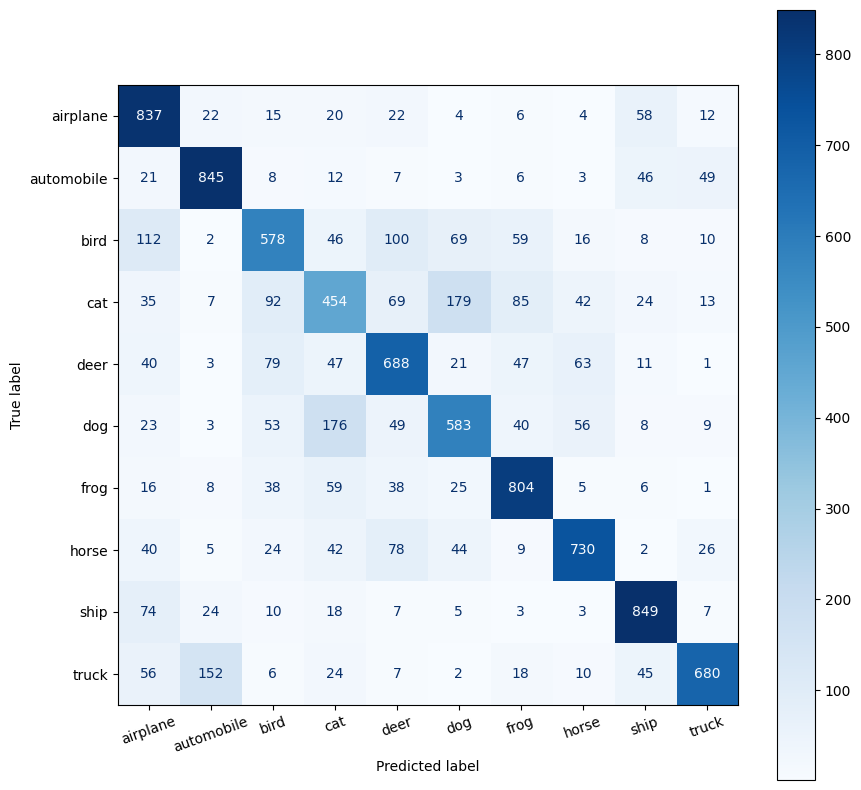

In [65]:
plot_confusion_matrix(labels, pred_labels, classes)

## Analysis of samples predicted wrongly
Here we will find the samples that the model is predicting wrongly and we will. Especifically, we will look at those samples that the model is predicting wrongly with a high score for the wrong class

We can then find which predictions were correct and then sort the incorrect predictions in descending order of their confidence.

In [66]:
corrects = torch.eq(labels, pred_labels)

In [67]:
incorrect_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects):
    if not correct:
        incorrect_examples.append((image, label, prob))

incorrect_examples.sort(reverse = True, key = lambda x: torch.max(x[2], dim = 0).values)

In [68]:
def plot_most_incorrect(incorrect, classes, n_images, normalize = True):

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize = (25, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image, true_label, probs = incorrect[i]
        image = image.permute(1, 2, 0)
        true_prob = probs[true_label]
        incorrect_prob, incorrect_label = torch.max(probs, dim = 0)
        true_class = classes[true_label]
        incorrect_class = classes[incorrect_label]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.cpu().numpy())
        ax.set_title(f'true label: {true_class} ({true_prob:.3f})\n' \
                     f'pred label: {incorrect_class} ({incorrect_prob:.3f})')
        ax.axis('off')

    fig.subplots_adjust(hspace = 0.4)

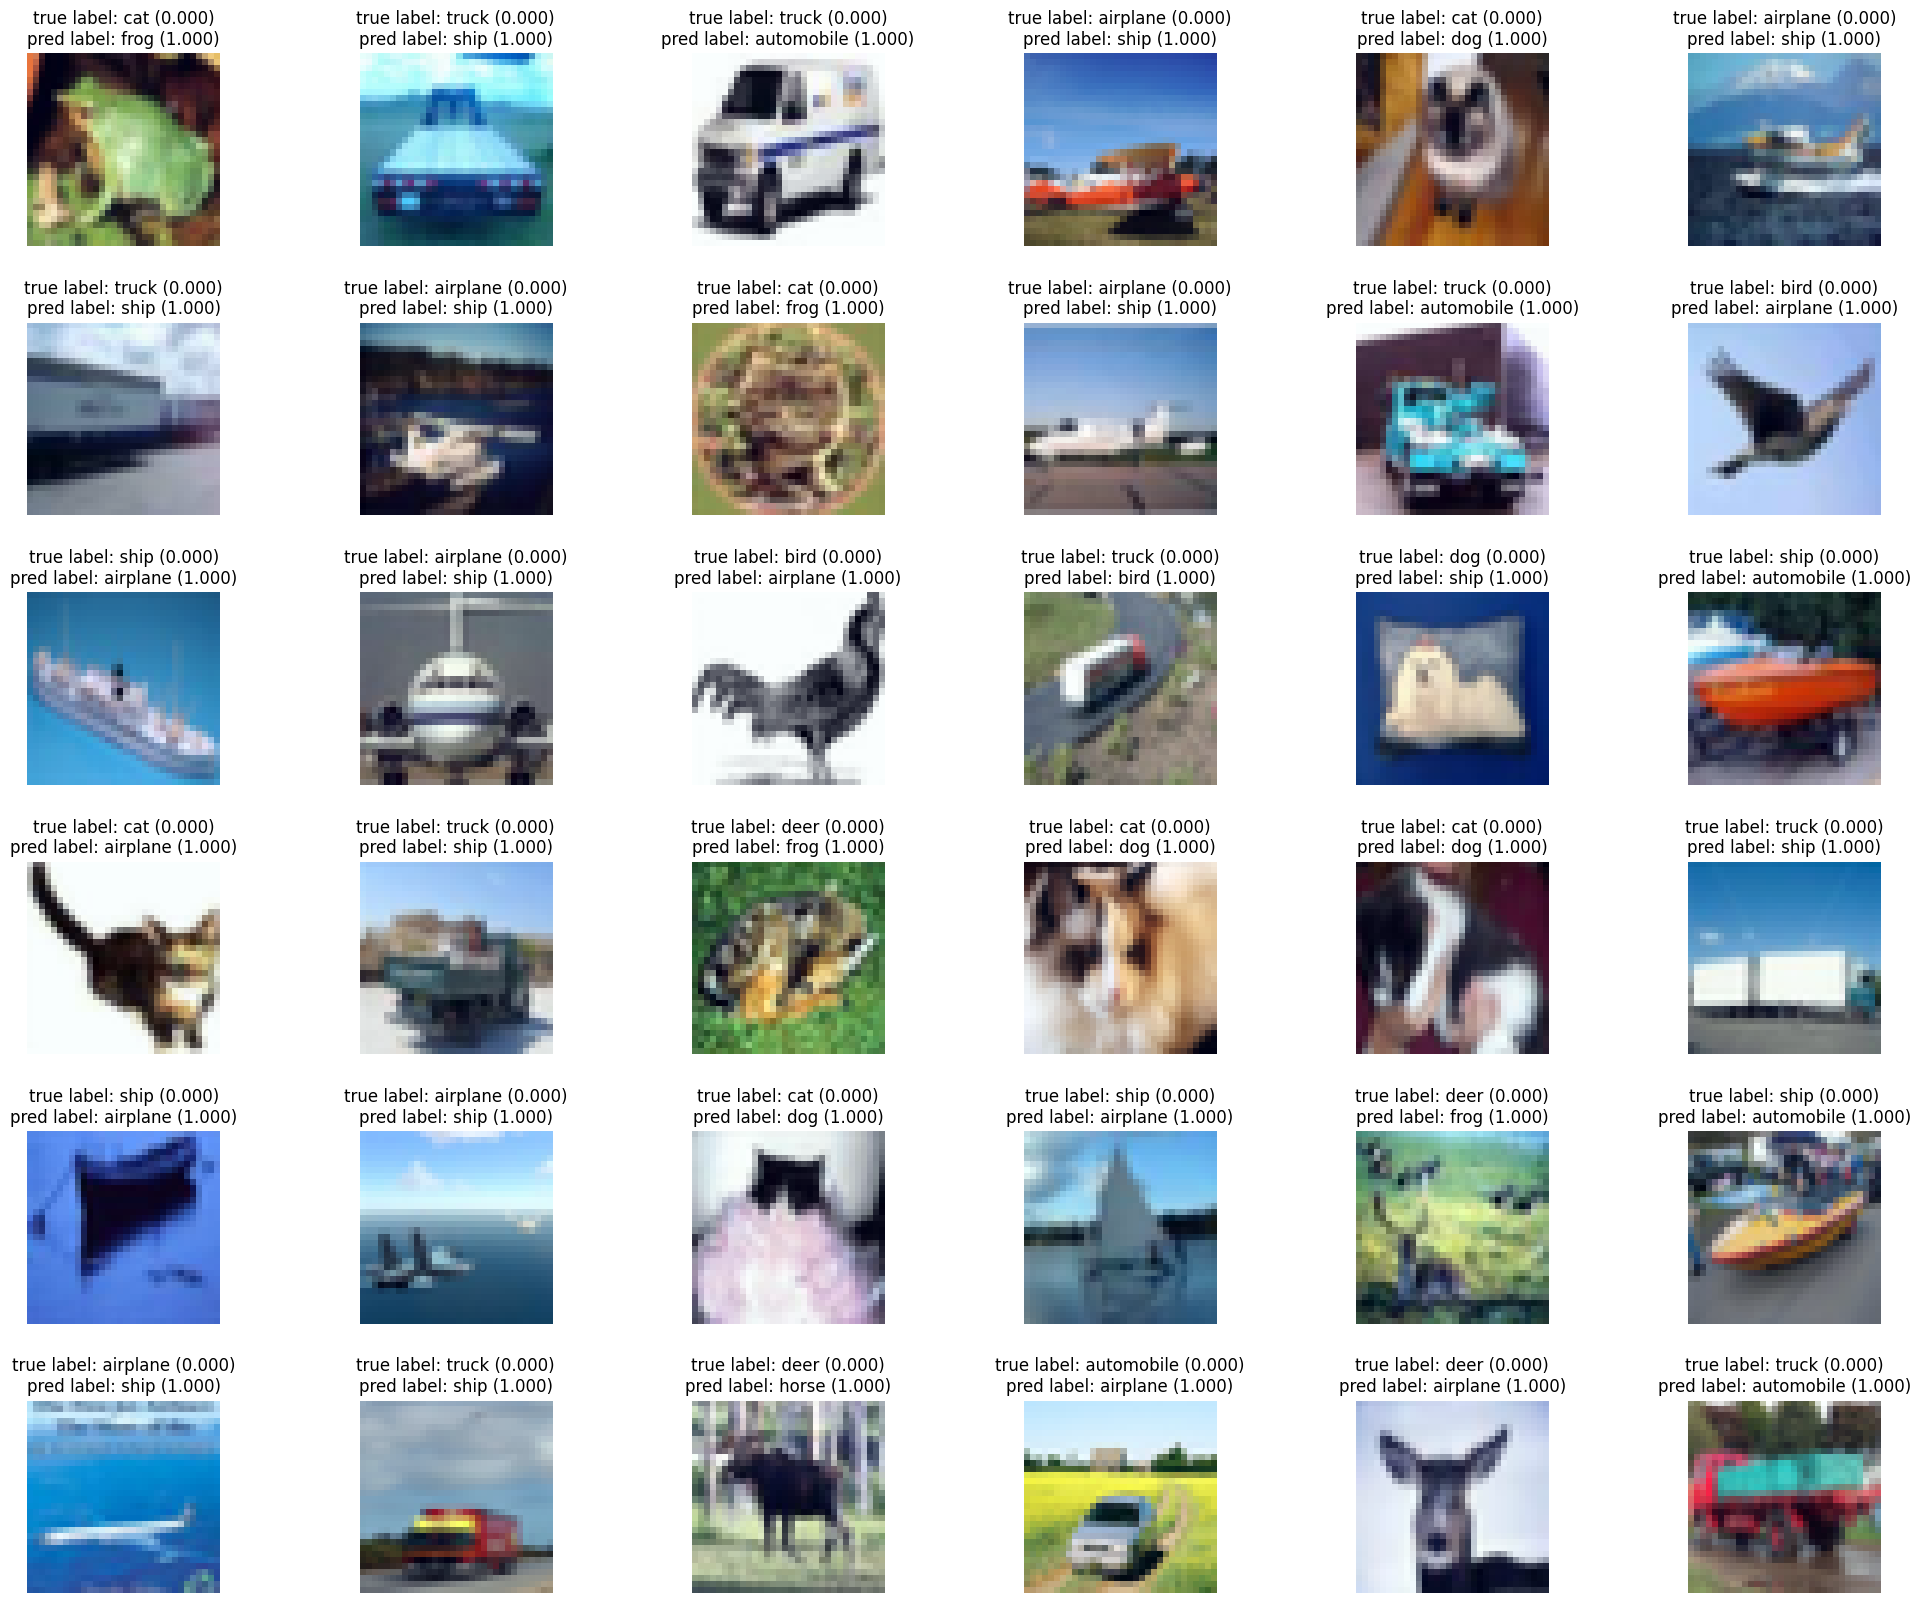

In [69]:
N_IMAGES = 36

plot_most_incorrect(incorrect_examples, classes, N_IMAGES)

# T-SNE representations: final  layer

In [70]:
def get_representations(model, iterator, device):

    model.eval()

    outputs = []
    intermediates = []
    labels = []

    with torch.no_grad():

        for (x, y) in iterator:

            x = x.to(device)

            y_pred, interm_feats = model(x)

            outputs.append(y_pred.cpu())
            intermediates.append(interm_feats.cpu())
            labels.append(y)

    outputs = torch.cat(outputs, dim = 0)
    intermediates = torch.cat(intermediates, dim = 0)
    labels = torch.cat(labels, dim = 0)

    return outputs, intermediates, labels
    # return outputs, labels

In [71]:
outputs, intermediates, labels = get_representations(model, valid_loader, device)

In [72]:
def plot_representations(data, labels, classes, n_images = None):

    if n_images is not None:
        data = data[:n_images]
        labels = labels[:n_images]

    fig = plt.figure(figsize = (10, 10))
    ax = fig.add_subplot(111)
    scatter = ax.scatter(data[:, 0], data[:, 1], c = labels, cmap = 'tab10')
    handles, labels = scatter.legend_elements()
    legend = ax.legend(handles = handles, labels = classes)

In [73]:
def get_tsne(data, n_components = 2, n_images = None):

    if n_images is not None:
        data = data[:n_images]

    tsne = manifold.TSNE(n_components = n_components, random_state = 0)
    tsne_data = tsne.fit_transform(data)
    return tsne_data

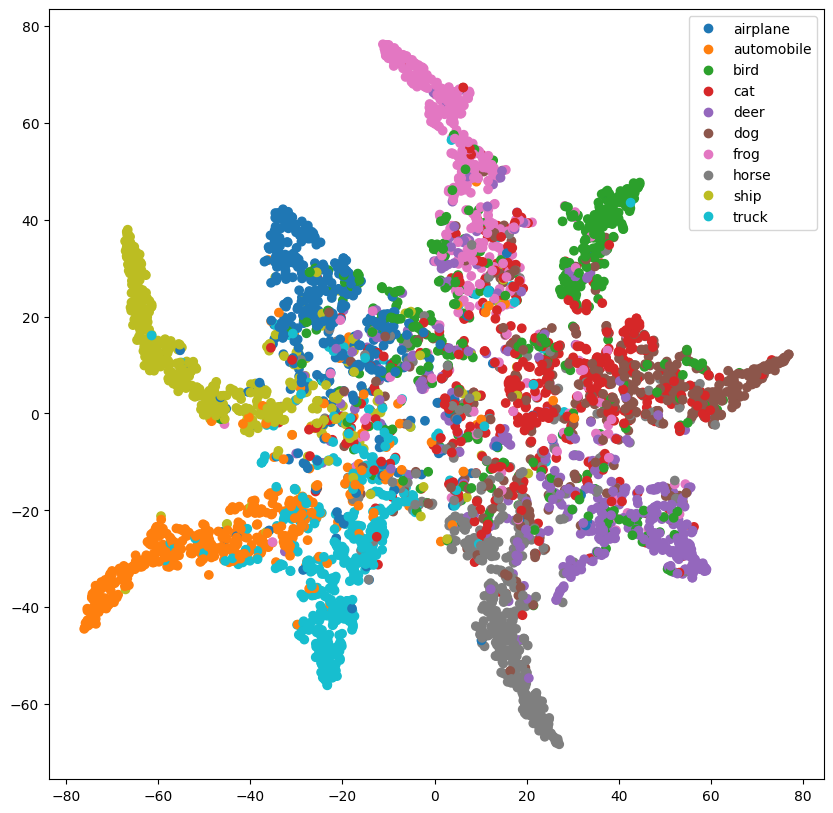

In [74]:
N_IMAGES = 5_000

output_tsne_data = get_tsne(outputs, n_images = N_IMAGES)
plot_representations(output_tsne_data, labels, classes, n_images = N_IMAGES)

# Visualization of filters




Next, we'll plot some images after they have been convolved with the first convolutional layer.

In [75]:
def plot_filtered_images(images, filters, n_filters = None, normalize = True):

    images = torch.cat([i.unsqueeze(0) for i in images], dim = 0).cpu()
    filters = filters.cpu()

    if n_filters is not None:
        filters = filters[:n_filters]

    n_images = images.shape[0]
    n_filters = filters.shape[0]

    filtered_images = F.conv2d(images, filters)

    fig = plt.figure(figsize = (30, 30))

    for i in range(n_images):

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax = fig.add_subplot(n_images, n_filters+1, i+1+(i*n_filters))
        ax.imshow(image.permute(1,2,0).numpy())
        ax.set_title('Original')
        ax.axis('off')

        for j in range(n_filters):
            image = filtered_images[i][j]

            if normalize:
                image = normalize_image(image)

            ax = fig.add_subplot(n_images, n_filters+1, i+1+(i*n_filters)+j+1)
            ax.imshow(image.numpy(), cmap = 'bone')
            ax.set_title(f'Filter {j+1}')
            ax.axis('off');

    fig.subplots_adjust(hspace = -0.7)

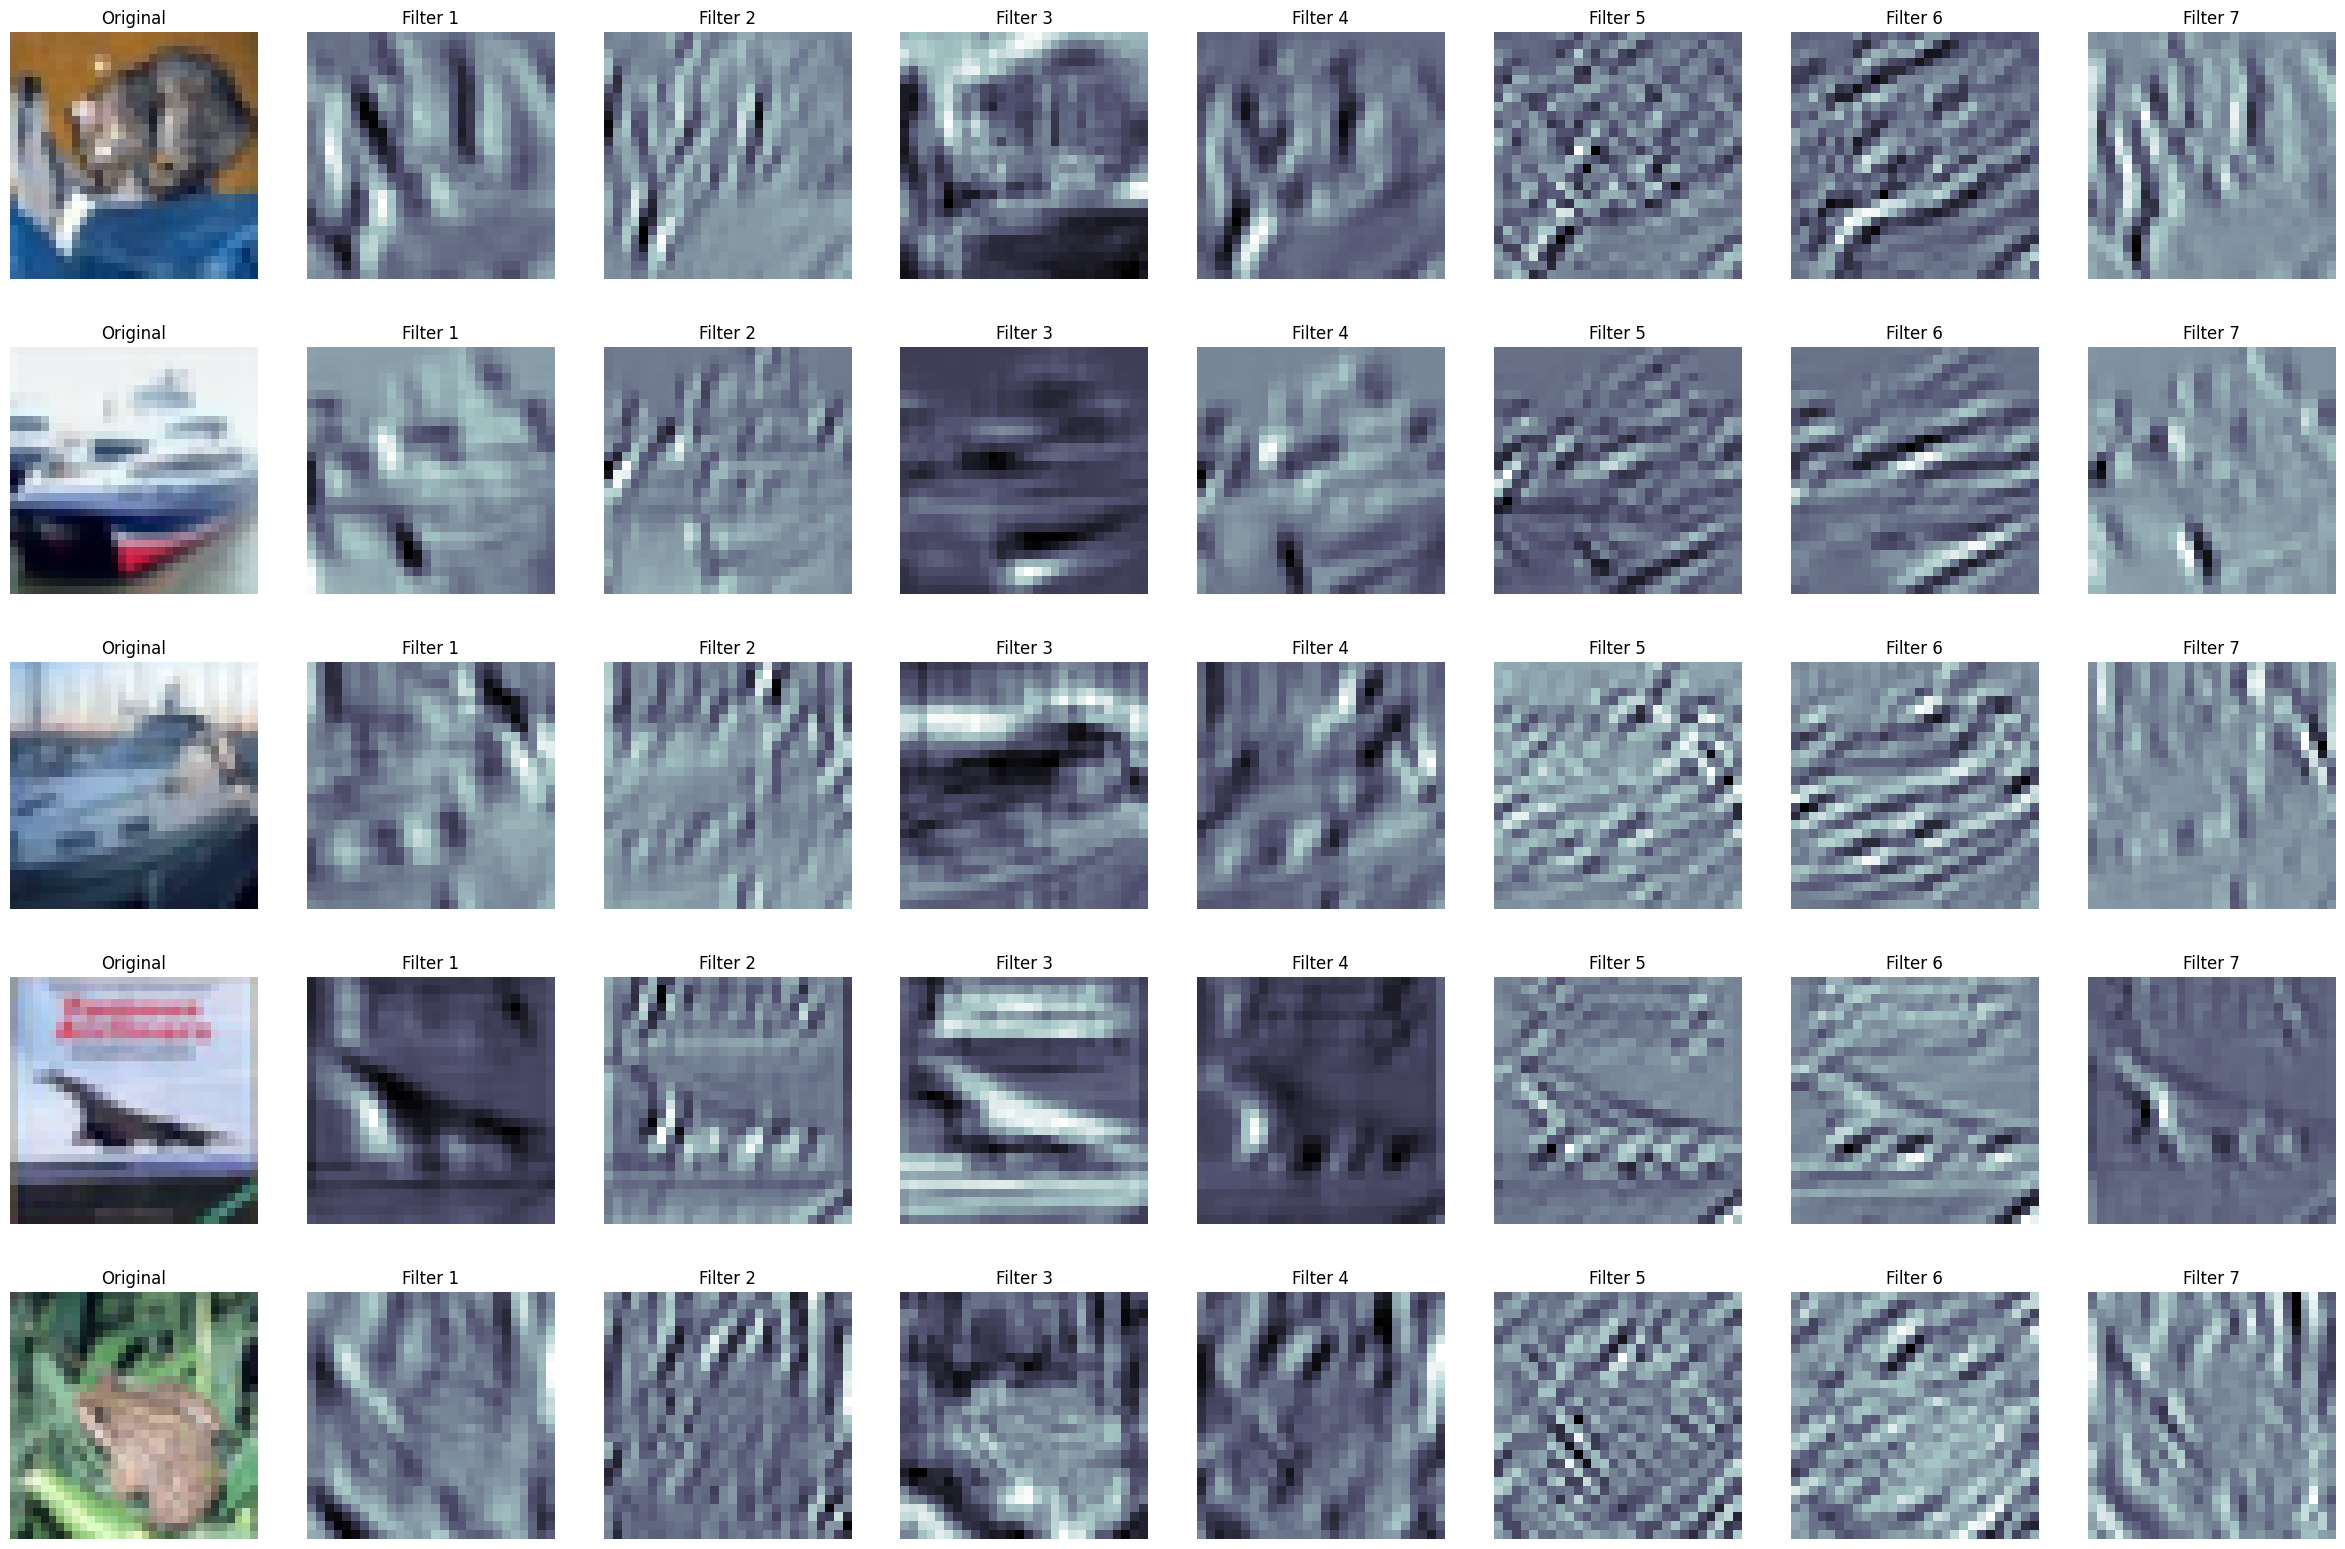

In [76]:
N_IMAGES = 5
N_FILTERS = 7

images = []
images = [image for image, label in [valid_set[i] for i in range(N_IMAGES)]]
filters = model.features[0].weight.data

plot_filtered_images(images, filters, N_FILTERS)

We can see different types of edge detection and blurring that the filters have learned that are apparently decent feature extractors for this model and task.

Finally, we can plot the actual filters our model has learned.

In [77]:
def plot_filters(filters, normalize = True):

    filters = filters.cpu()

    n_filters = filters.shape[0]

    rows = int(np.sqrt(n_filters))
    cols = int(np.sqrt(n_filters))

    fig = plt.figure(figsize = (20, 10))

    for i in range(rows*cols):

        image = filters[i]

        if normalize:
            image = normalize_image(image)

        ax = fig.add_subplot(rows, cols, i+1)
        ax.imshow(image.permute(1, 2, 0))
        ax.axis('off')

    fig.subplots_adjust(wspace = -0.9)

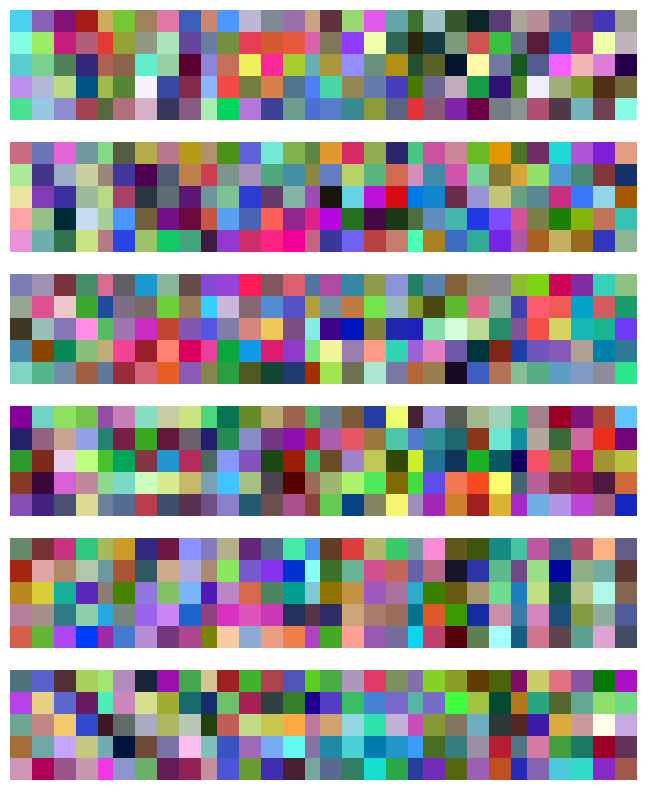

In [78]:
plot_filters(filters)

Sadly, there is nothing really interpretable here.

Can we learn interesting looking filters? Or are we doomed to just look at colorful blocks?

Well, we can take a *pre-trained* AlexNet model and view the filters of that. This pre-trained version of AlexNet was trained by people at PyTorch and was not trained on the CIFAR10 dataset, but on the [ILSVRC](https://arxiv.org/abs/1409.0575) dataset, usually just called the ImageNet dataset. ImageNet is a dataset with over 1 million images in 1,000 classes. Torchvision provides ways of downloading different models pre-trained on ImageNet, such as AlexNet and [many others](https://pytorch.org/docs/stable/torchvision/models.html).  

First, we can import the model making sure to pass `pretrained = True` to get a pre-trained version. Torchvision will then import the model, download the weights for it and load them into the new model.

We can see that this is similar to our AlexNet model but has considerably more parameters.

One interesting thing is that they use much larger filters in the first convolutional layer - 11x11 instead of 5x5.

In [79]:
import torchvision.models as models

model = models.alexnet(pretrained = True)

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

We can then get the learned values of these filters the same way we did for our version of AlexNet and then plot them.

As we can see the patterns are much more interesting. So how come it learned these interesting looking filters? Is it just because the filters are bigger? Is it because models can only do well on ImageNet if they learn these types of filters? Do these more interesting looking filters imply that they perform better? Or are these filters showing how the model has overfit to patterns on the images within ImageNet?

It is difficult to answer these questions, and network interpretability is one of the still open questions in the research community.

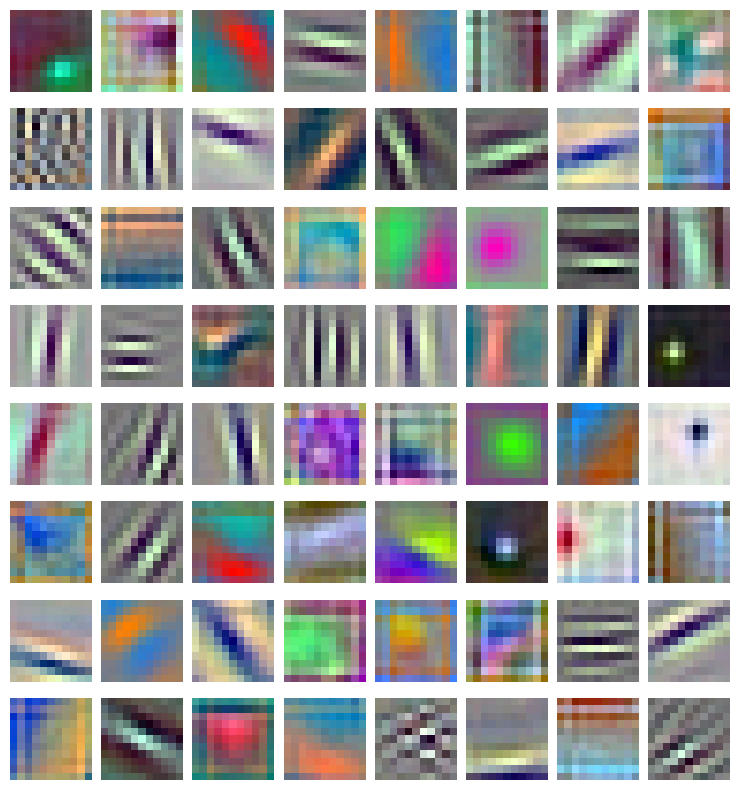

In [80]:
filters_imagenet = model.features[0].weight.data

plot_filters(filters_imagenet)

# Residual Networks: Basic Residual Network

Finally, we will implement a basic residual network with skip connections between layers.  We will evaluate its performance over the same dataset and compare it with the non-residual architecture (Alexnet), in terms of performance and network complexity

## Residual connections

A residual connection is simply a direct connection between the input of a block and the output of a block. Sometimes the residual connection has layers in it, but most of the time it does not. Below is an example block with an identity residual connection, i.e. no layers in the residual path.

![](https://github.com/bentrevett/pytorch-image-classification/blob/master/assets/resnet-skip.png?raw=1)

Why do ResNets work? The key is in the residual connections. Training incredibly deep neural networks is difficult due to the gradient signal either exploding (becoming very large) or vanishing (becoming very small) as it gets backpropagated through many layers. Residual connections allow the model to learn how to "skip" layers - by setting all their weights to zero and only rely on the residual connection. Thus, in theory, if your ResNet152 model can actually learn the desired function between input and output by only using the first 52 layers the remaining 100 layers should set their weights to zero and the output of the 52nd layer will simply pass through the residual connections unhindered. This also allows for the gradient signal to also backpropagate through those 100 layers unhindered too. In theory, this outcome could also also be achieved in a network without residual connections: the "skipped" layers would learn to set their weights to one, however adding the residual connection is more explicit and is easier for the model to learn to use these residual connections.

The image below shows a comparison between VGG-19, a convolutional neural network architecture without residual connections, and one with residual connections - ResNet34.

![](https://github.com/bentrevett/pytorch-image-classification/blob/master/assets/vgg-resnet.png?raw=1)


# Defining the Model
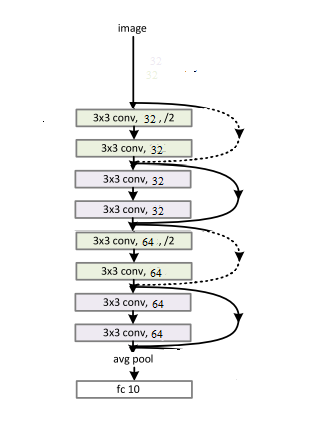




We will implement a similar architecture to the ResNet shown in the figure above. Our simplified model will have the following differences:

* We will skip the initial 7x7 and pooling layers
* We will use 8 3x3 conv layers stacked as shown in the figure
* The green blocks correspond to residual blocks with additional downsampling (downsampling blocks). The first convolutional layer downsamples the input by a factor of 2, using the stride parameter, and sets the number of feature channels. Also, in these blocks, the input needs to be resized to be added to the output
* The pink residual blocks maintain all dimensions unaltered





Let's define the basic residual block. We have two options:
* Downsampling blocks: the input is filtered by a 1x1 convolution that also reduces the spatial resolution by a factor of 2.
* Non-downsampling: spatial and channel resolutions are mantained

Note that we use Batch Normalization after each convolutional layer

In [81]:
class BasicResBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, stride = 1, padding = 1 , downsample = False):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size,
                               stride, padding, bias = False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace = True)

        # define the second conv and BN layers. This second layer does not change any dimensions in any case
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size,
                               stride=1, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)


        if downsample:
            # define a 1x1 convolutional layer for the input, that also reduces the spatial resolution
            # using the same stride value used in the conv1 layer
            conv1D = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                               stride=stride, padding=0,bias=False)

            bn = nn.BatchNorm2d(out_channels)
            downsample = nn.Sequential(conv1D, bn)
        else:
            downsample = None

        self.downsample = downsample

    def forward(self, x):

       # we save the input to add it later (skip connection)
        i = x

        # apply conv, bn, and relu layers to the input in the same order
        # that they are defined
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.downsample is not None:
            i = self.downsample(i)

        # add input (implement skip connection) and a final relu layer
        x = x + i
        x = self.relu(x)

        return x


We will use the Basic Residual Block to implement the architecture of the Basic Residual Network  

In [82]:
class BasicResNet(nn.Module):
    def __init__(self, output_dim):
        super().__init__()

        # define the 8 convolutional layers using the BasicResBlock (4 blocks)
        self.layer1 = BasicResBlock(3, 16, kernel_size=3, stride=2, padding=1, downsample=True)
        self.layer2 = BasicResBlock(16, 32, kernel_size=3, stride=2, padding=1, downsample=True)
        self.layer3 = BasicResBlock(32, 64, kernel_size=3, stride=2, padding=1, downsample=True)
        # The pink block: maintains dimensions unaltered
        self.layer4 = BasicResBlock(64, 64, kernel_size=3, stride=1, padding=1, downsample=False)

        # define an adaptive average pooling layer with an output size of 2x2
        # use nn.AdaptiveAvgPool2d
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))

        # classifier with 1 layer
        self.classifier = nn.Sequential(
            # First linear layer
            nn.Dropout(0.5),
            nn.Linear(64 * 2 * 2, output_dim),
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)

        interm_features = x.view(x.shape[0], -1)
        x = self.classifier(interm_features)
        return x, interm_features

The code below is used to check that the model architecture is defined correctly. The code should not return any error, and the output should be the following:

```
Output size:  torch.Size([1, 5])
Output: tensor([[-0.3847, -0.6278, -0.2398, -0.5358, -0.4676]],
       grad_fn=<AddmmBackward0>)
```



In [83]:
SEED = 1234
torch.manual_seed(SEED)

dummy_input = torch.rand(1,3,32,32)
model = BasicResNet(5)
output = model(dummy_input)

print('Output size: ',format(output[0].shape))
print('Output:')
print(output[0])

Output size:  torch.Size([1, 5])
Output:
tensor([[ 1.0244, -0.6697,  1.5849, -0.8036, -0.2715]],
       grad_fn=<AddmmBackward0>)


In [84]:
model = BasicResNet(10)

model.to(device)

BasicResNet(
  (layer1): BasicResBlock(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): BasicResBlock(
    (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1

In [85]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 151,690 trainable parameters


# Training the Model

Use the code from previous notebook to train the model for 15 epochs **(with a learning rate of 0.005)** and plot the learning curves



Starting ResNet training...
Epoch: 01 | Epoch Time: 0m 17s
	Train Loss: 1.538 | Train Acc: 43.43%
	 Val. Loss: 1.257 |  Val. Acc: 53.05%
Epoch: 02 | Epoch Time: 0m 16s
	Train Loss: 1.146 | Train Acc: 58.60%
	 Val. Loss: 1.053 |  Val. Acc: 62.38%
Epoch: 03 | Epoch Time: 0m 17s
	Train Loss: 0.970 | Train Acc: 65.45%
	 Val. Loss: 0.944 |  Val. Acc: 66.08%
Epoch: 04 | Epoch Time: 0m 17s
	Train Loss: 0.847 | Train Acc: 70.30%
	 Val. Loss: 0.943 |  Val. Acc: 66.34%
Epoch: 05 | Epoch Time: 0m 17s
	Train Loss: 0.759 | Train Acc: 73.27%
	 Val. Loss: 0.935 |  Val. Acc: 67.75%
Epoch: 06 | Epoch Time: 0m 16s
	Train Loss: 0.681 | Train Acc: 76.17%
	 Val. Loss: 0.853 |  Val. Acc: 70.96%
Epoch: 07 | Epoch Time: 0m 17s
	Train Loss: 0.618 | Train Acc: 78.25%
	 Val. Loss: 0.813 |  Val. Acc: 72.25%
Epoch: 08 | Epoch Time: 0m 17s
	Train Loss: 0.558 | Train Acc: 80.46%
	 Val. Loss: 0.813 |  Val. Acc: 72.27%
Epoch: 09 | Epoch Time: 0m 17s
	Train Loss: 0.509 | Train Acc: 82.02%
	 Val. Loss: 0.866 |  Val. Acc

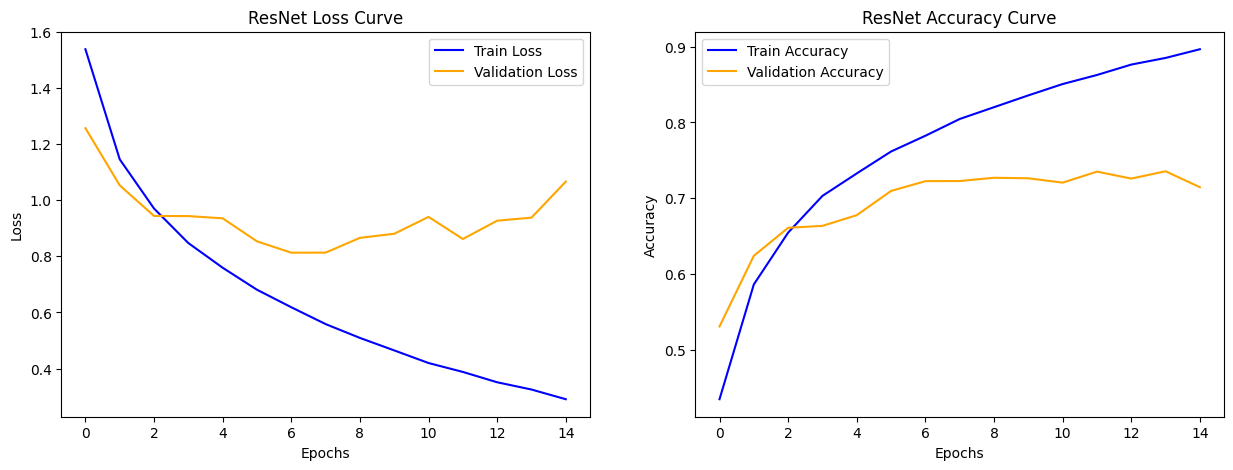

In [86]:

optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()
criterion = criterion.to(device)

def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc = 0
    model.train()

    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred, _ = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc = 0
    model.eval()

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)

            y_pred, _ = model(x)
            loss = criterion(y_pred, y)
            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

# 5. Execute Training Loop for 15 Epochs
EPOCHS = 15

train_losses = []
valid_losses = []
train_accs = []
valid_accs = []

best_valid_loss = float('inf')

print("Starting ResNet training...")
for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)

    # Save the best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'resnet-model.pt')

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {int(epoch_mins)}m {int(epoch_secs)}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# plot loss
ax[0].plot(train_losses, label='Train Loss', color='blue')
ax[0].plot(valid_losses, label='Validation Loss', color='orange')
ax[0].set_title('ResNet Loss Curve')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

# plot accuracy
ax[1].plot(train_accs, label='Train Accuracy', color='blue')
ax[1].plot(valid_accs, label='Validation Accuracy', color='orange')
ax[1].set_title('ResNet Accuracy Curve')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.show()